## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

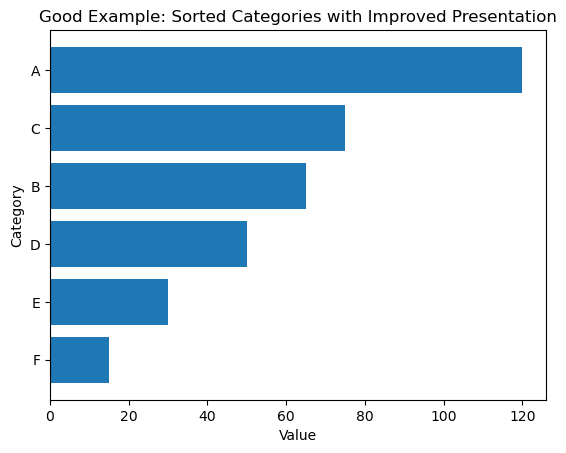

In [16]:
df_demo = pd.DataFrame({
    "category": ["A", "B", "C", "D", "E", "F"],
    "value": [120, 65, 75, 50, 30, 15]
})

df_demo_sorted = df_demo.sort_values(by="value")

plt.figure()
plt.barh(df_demo_sorted["category"], df_demo_sorted["value"])
plt.title("Good Example: Sorted Categories with Improved Presentation")
plt.ylabel("Category")
plt.xlabel("Value")
plt.show()

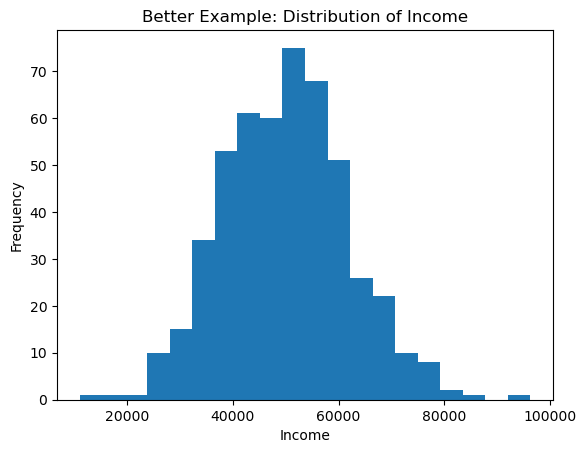

In [6]:
np.random.seed(42)
df_distribution = pd.DataFrame({
    "income": np.random.normal(50000, 12000, 500)
})

plt.figure()
plt.hist(df_distribution["income"], bins=20)
plt.title("Better Example: Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

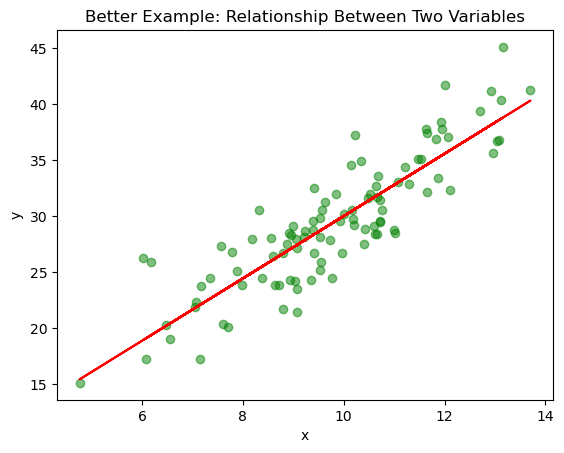

In [31]:
np.random.seed(42)
x = np.random.normal(10, 2, 100)
y = x * 3 + np.random.normal(0, 3, 100)

df_relationship = pd.DataFrame({
    "x": x,
    "y": y
})

plt.figure()
plt.scatter(df_relationship["x"], df_relationship["y"], c="green", alpha=0.5)
plt.title("Better Example: Relationship Between Two Variables")
plt.xlabel("x")
plt.ylabel("y")
plt.plot(df_relationship["x"], np.poly1d(plt.trend_line)(df_relationship["x"]), color="red")
plt.show()

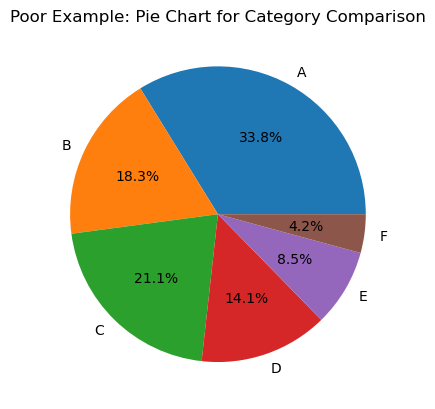

In [21]:
plt.figure()
plt.pie(df_demo["value"], labels=df_demo["category"], autopct="%1.1f%%")
plt.title("Poor Example: Pie Chart for Category Comparison")
plt.show()

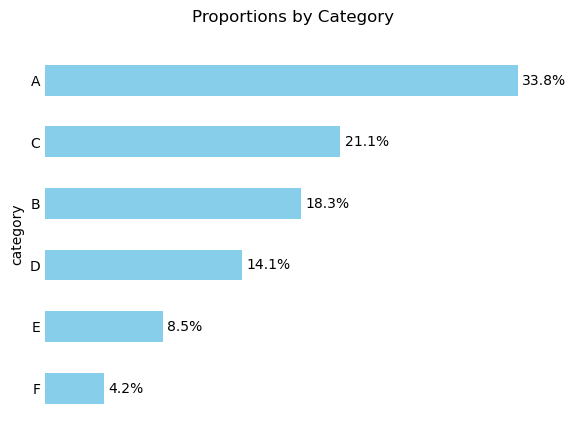

In [33]:
# 1. Calculate proportions (0.0 to 1.0)
df_demo['prop'] = df_demo['value'] / df_demo['value'].sum()

# 2. Sort by proportion for a cleaner look
df_demo = df_demo.sort_values('prop')

# 3. Plot as horizontal bars
ax = df_demo.plot(kind='barh', x='category', y='prop', color='skyblue', legend=False)

# 4. Add annotations using bar_label
# labels=[...] allows us to format the numbers as percentages
ax.bar_label(ax.containers[0], 
             labels=[f'{x:.1%}' for x in df_demo['prop']], 
             padding=3)

# --- THE CLEANUP ---

# 1. Remove the X-axis completely
ax.get_xaxis().set_visible(False)

# 2. Remove all borders (spines)
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(False)

# 3. Remove the tick marks on the Y-axis for a total "floating" look
ax.tick_params(axis='both', which='both', length=0)

plt.title("Proportions by Category", pad=20)
plt.show()


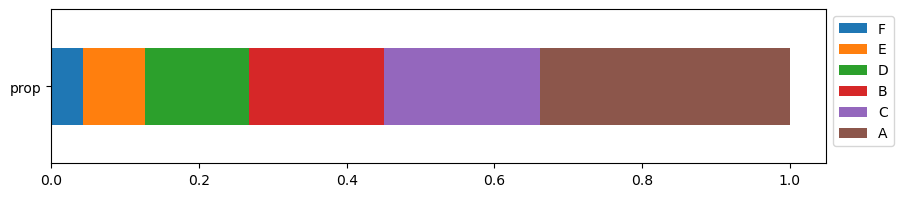

In [24]:
# Transpose data to stack it
df_total = df_demo.set_index('category')['prop'].to_frame().T

# Plot a single horizontal bar where all parts add up to 100%
df_total.plot(kind='barh', stacked=True, figsize=(10, 2))
plt.legend(bbox_to_anchor=(1.0, 1.0))
plt.show()

## Dummy data for the example

In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/dummy_data.csv")
print(df.shape)
# Preview the data
df.head()

(300, 6)


,customer_id,age,region,segment,income,monthly_spend
0,1,56,West,Medium Value,63353.0,2411.0
1,2,69,East,Medium Value,64900.0,2688.0
2,3,46,East,Low Value,47074.0,1147.0
3,4,32,North,High Value,30267.0,1671.0
4,5,60,North,High Value,44233.0,2753.0


In [3]:
import plotly.express as px

fig = px.scatter(
    data_frame=df, # data
    x="age", # x aesthetic
    y="income", # y aesthetic
    color="segment", # color aesthetic
    size="monthly_spend", # size aesthetic
    facet_col="region", # facet
    trendline="ols", # statistical layer
    title="Relationship Between Customer Age and Income"
)

fig.show()

In [4]:
sales_by_region = (
    df
    .groupby("region", as_index=False)
    .agg(
        total_sales=("monthly_spend", "sum"),
        avg_sales=("monthly_spend", "mean"),
        number_of_customers=("customer_id", "count")
    )
)

In [6]:
col_list = ["region", "total_sales", "avg_sales", "number_of_customers"]
y_axis_arg_list = ["total_sales", "avg_sales", "number_of_customers"]
y_axis_title_list = ["Total Sales", "Average Sales", "Number of Customers"]

for y_axis_arg, y_axis_title in zip(y_axis_arg_list, y_axis_title_list):
    fig = px.bar(
        data_frame=sales_by_region,
        x="region",
        y=y_axis_arg,
        title=f"{y_axis_title} by Region"
    )
    fig.show()

# fig = px.bar(
#     data_frame=sales_by_region,
#     x="region",
#     y="total_sales",
#     title="Total Sales by Region"
# )

# fig.show()

In [7]:
daily_sales = (
    df
    .assign(
        date=pd.date_range(
            start="2026-01-01",
            periods=len(df),
            freq="D"
        )
    )
    .groupby("date", as_index=False)
    .agg(
        sales=("monthly_spend", "sum"),
        number_of_customers=("customer_id", "count"),
        avg_sales=("monthly_spend", "mean")
    )
)

# Round values for cleaner display
daily_sales["sales"] = daily_sales["sales"].round(0)
daily_sales["avg_sales"] = daily_sales["avg_sales"].round(2)

daily_sales.head()

,date,sales,number_of_customers,avg_sales
0,2026-01-01,2411.0,1,2411.0
1,2026-01-02,2688.0,1,2688.0
2,2026-01-03,1147.0,1,1147.0
3,2026-01-04,1671.0,1,1671.0
4,2026-01-05,2753.0,1,2753.0


In [8]:
fig = px.line(
    data_frame=daily_sales,
    x="date",
    y="sales",
    title="Sales Trend Over Time"
)

fig.show()